# Vision Debugging Notebook

Use this notebook to test the `BoardDetector`, tune HSV values, and verify perspective transformation.

In [20]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath('..'))

from pefforza.vision.board_detector import BoardDetector

def show_img(img, title="Image"):
    # Convert BGR to RGB for matplotlib
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

### 1. Capture a Frame
Make sure your camera is connected. We will capture one frame to work with.

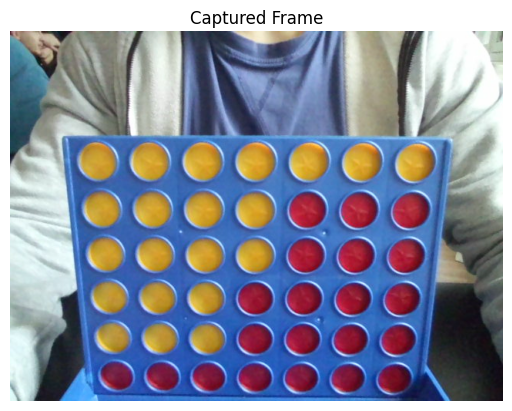

In [24]:
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

if ret:
    show_img(frame, "Captured Frame")
else:
    print("Failed to capture frame")

### 2. Manual Calibration (Test)
Since we can't easily click in a notebook, let's manually define points or load a dummy matrix if we had one.
Alternatively, run this cell then check the output to see if it works. 
For this notebook, we'll just try to instantiate the detector and check its methods.

In [25]:
detector = BoardDetector()
print("Detector initialized. Width:", detector.width, "Height:", detector.height)

Detector initialized. Width: 700 Height: 600


### 3. Mask Testing (HSV Tuning)
Adjust the values below to see what the detector perceives as 'Red' or 'Yellow'.

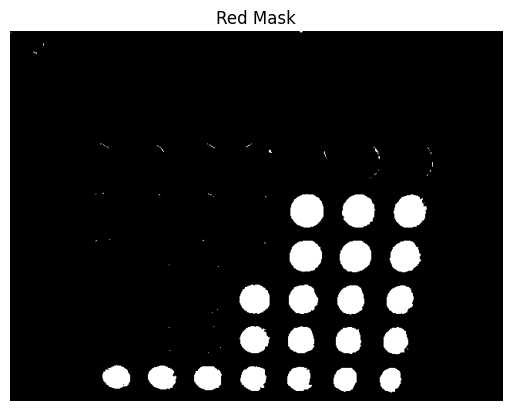

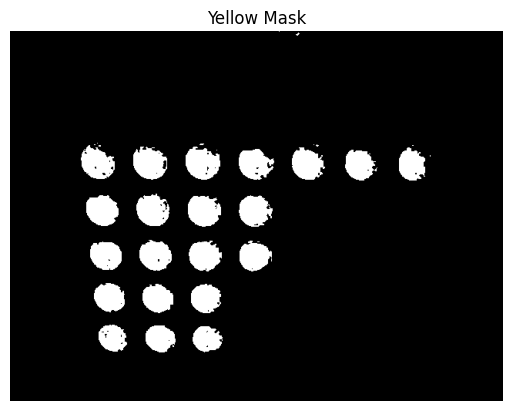

In [30]:
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

# Example: Red Mask
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([13, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask_red = mask1 | mask2

show_img(mask_red, "Red Mask")

# Yellow Mask
lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([30, 255, 255])
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

show_img(mask_yellow, "Yellow Mask")